#Perkenalan

<p><b>================================================================================================</b><br>
Milestoes 2 <br>
<br>
Nama    : Abdan Primamukti<br>
Batch   : HCK-027<br>
<br>
Menganalisis data dan membangun model Machine Learning untuk memprediksi kategori obesitas seseorang berdasarkan berbagai fitur, seperti usia, tinggi, berat, riwayat keluarga, kebiasaan makan, dan gaya hidup. Proyek ini bertujuan untuk memahami faktor-faktor yang berkontribusi terhadap obesitas dan mengembangkan model prediksi yang akurat.
<br><br>
<b>================================================================================================</b></p>

| Kolom          | Tipe Data | Penjelasan                                                    |
| :------------- | :-------- | :------------------------------------------------------------ |
| **Gender**     | `object`  | Jenis kelamin partisipan (misalnya, 'Male', 'Female').      |
| **Age**        | `float64` | Usia partisipan dalam format desimal.                         |
| **Height**     | `float64` | Tinggi partisipan dalam format desimal.                       |
| **Weight**     | `float64` | Berat partisipan dalam format desimal.                        |
| **family_history**| `object` | Riwayat obesitas dalam keluarga (misalnya, 'yes', 'no').      |
| **FAVC**       | `object`  | Konsumsi makanan berkalori tinggi secara sering.              |
| **FCVC**       | `float64` | Frekuensi konsumsi sayuran.                                   |
| **NCP**        | `float64` | Jumlah makanan utama.                                         |
| **CAEC**       | `object`  | Konsumsi makanan di antara waktu makan.                       |
| **SMOKE**      | `object`  | Status merokok partisipan (misalnya, 'yes', 'no').            |
| **CH2O**       | `float64` | Konsumsi air harian.                                          |
| **SCC**        | `object`  | Pemantauan konsumsi kalori.                                   |
| **FAF**        | `float64` | Frekuensi aktivitas fisik.                                    |
| **TUE**        | `float64` | Waktu menggunakan perangkat teknologi.                        |
| **CALC**       | `object`  | Konsumsi alkohol.                                             |
| **MTRANS**     | `object`  | Transportasi yang digunakan.                                  |
| **Obesity**    | `object`  | Kategori obesitas partisipan (Variabel Target).               |

#Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score,ConfusionMatrixDisplay

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


#Data Loading

In [27]:
df_asli = pd.read_csv('Obesity prediction.csv')
df = df_asli.copy()
df

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

#Exploratory Data Analysis (EDA)

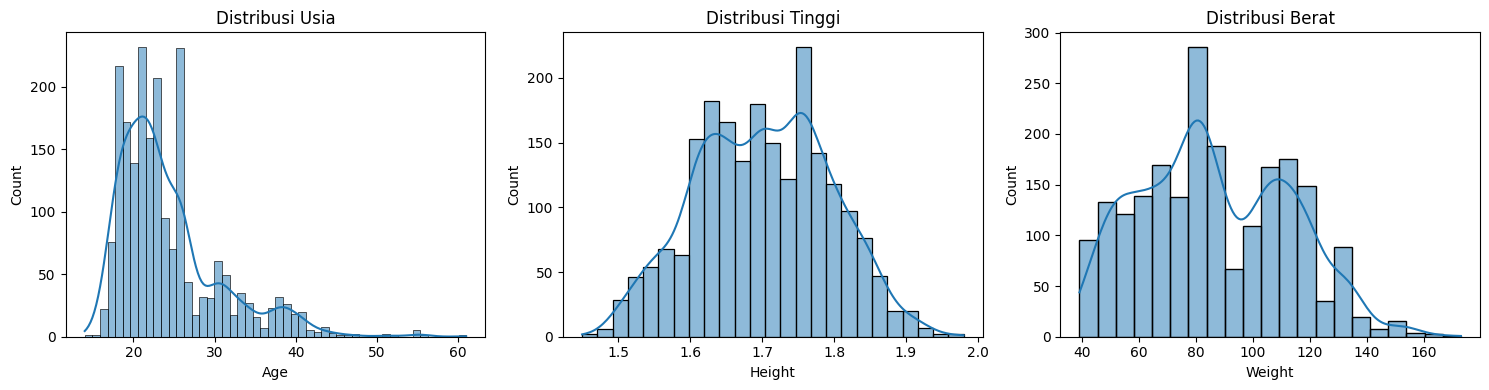

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Usia')

sns.histplot(df['Height'], kde=True, ax=axes[1])
axes[1].set_title('Distribusi Tinggi')

sns.histplot(df['Weight'], kde=True, ax=axes[2])
axes[2].set_title('Distribusi Berat')
plt.tight_layout()
plt.show()


Gambar ini menunjukkan distribusi dari tiga variabel: Usia (Age), Tinggi (Height), dan Berat (Weight).

**Distribusi Usia:** Distribusi usia menunjukkan adanya konsentrasi yang tinggi pada kelompok usia muda, terutama di bawah usia 30 tahun, dengan puncak yang jelas di sekitar usia 20 hingga 25 tahun. Setelah itu, frekuensi menurun dengan semakin bertambahnya usia, meskipun masih ada individu yang lebih tua dalam distribusi.

**Distribusi Tinggi:** Distribusi tinggi menunjukkan pola yang lebih simetris dengan puncak di sekitar tinggi 1.7 meter, yang merupakan tinggi rata-rata pada populasi ini. Sebagian besar individu memiliki tinggi tubuh di sekitar rentang 1.6 hingga 1.8 meter, dengan sedikit individu yang memiliki tinggi lebih pendek atau lebih tinggi dari rentang ini.

**Distribusi Berat:** Distribusi berat tubuh menunjukkan pola distribusi yang lebih miring dengan puncak di sekitar 70 hingga 80 kg, yang menunjukkan bahwa sebagian besar individu dalam dataset ini memiliki berat badan di kisaran tersebut. Ada juga beberapa individu dengan berat badan yang lebih tinggi, tetapi distribusi ini menunjukkan kecenderungan ke arah berat badan yang lebih rendah hingga sedang.

Secara keseluruhan, distribusi ini memberikan gambaran yang jelas tentang karakteristik demografis dan fisik dari dataset ini, di mana mayoritas individu berada pada usia muda dengan tinggi rata-rata sekitar 1.7 meter dan berat badan di kisaran 70-80 kg.

<ipython-input-30-e74404a5c344>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Obesity', y='FCVC', data=df, palette='muted')


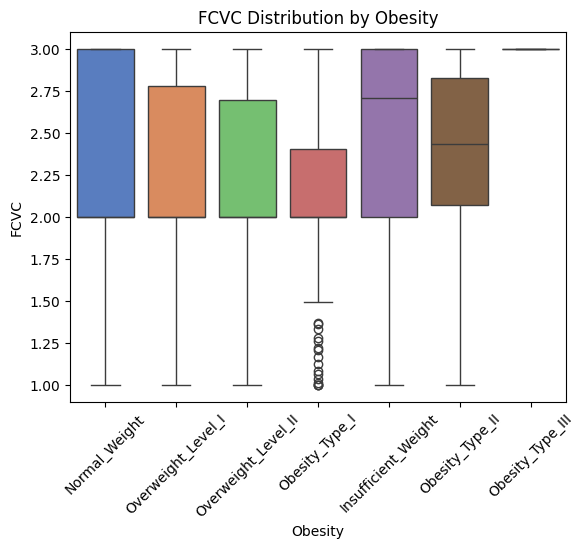

In [30]:
#Boxplot for FCVC by Obesity
sns.boxplot(x='Obesity', y='FCVC', data=df, palette='muted')
plt.title('FCVC Distribution by Obesity')
plt.xlabel('Obesity')
plt.ylabel('FCVC')
plt.xticks(rotation=45)
plt.show()

Gambar ini menunjukkan distribusi FCVC (Food Consumption Frequency) berdasarkan kategori obesitas yang meliputi Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II, dan Obesity Type III. Dari box plot ini, terlihat bahwa individu dengan Normal Weight cenderung memiliki nilai FCVC yang lebih tinggi, dengan rata-rata sekitar 2.5, meskipun ada sedikit variasi antar individu. Kategori Overweight Level I dan Overweight Level II menunjukkan nilai FCVC yang lebih rendah dibandingkan dengan kategori Normal Weight, dengan variasi yang lebih besar di Overweight Level II. Sementara itu, individu dengan Obesity Type I, Obesity Type II, dan terutama Obesity Type III menunjukkan nilai FCVC yang semakin rendah seiring meningkatnya tingkat obesitas, dengan Obesity Type III memiliki nilai FCVC yang paling rendah. Hal ini mengindikasikan bahwa individu dengan tingkat obesitas yang lebih tinggi cenderung memiliki pola konsumsi makanan yang lebih sedikit atau jarang. Individu dengan Insufficient Weight memiliki pola FCVC yang serupa dengan Obesity Type I, meskipun ada beberapa individu dengan nilai yang lebih rendah. Secara keseluruhan, data ini menunjukkan adanya pola yang menghubungkan frekuensi konsumsi makanan dengan tingkat obesitas, di mana konsumsi makanan lebih sedikit cenderung ditemukan pada individu dengan obesitas tingkat tinggi.

<ipython-input-31-de1a1ffa12b5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SMOKE', data=df, palette='coolwarm')


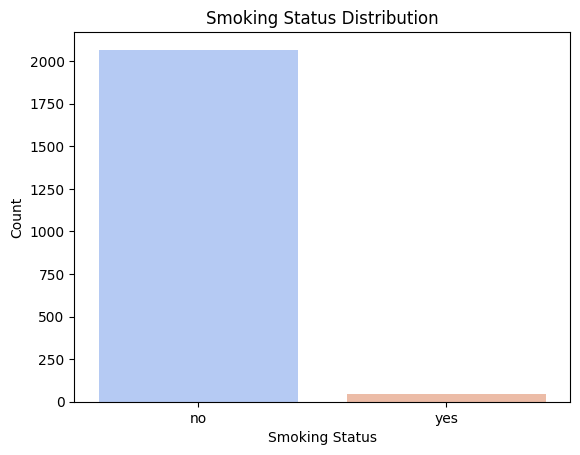

In [31]:
# Countplot for Smoking Status (SMOKE)
# Visualize the distribution of Smoking Status
sns.countplot(x='SMOKE', data=df, palette='coolwarm')
plt.title('Smoking Status Distribution')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.show()

Gambar ini menunjukkan distribusi status merokok dalam dataset, dengan dua kategori: "no" (tidak merokok) dan "yes" (merokok). Berdasarkan distribusi yang ditampilkan, dapat dilihat bahwa sebagian besar individu dalam dataset ini tidak merokok, dengan jumlah yang jauh lebih banyak dibandingkan dengan individu yang merokok. Hal ini menunjukkan ketidakseimbangan kelas yang signifikan, di mana kategori "no" (tidak merokok) mendominasi distribusi, sedangkan kategori "yes" (merokok) memiliki jumlah yang jauh lebih sedikit.

In [32]:
# Statistik dasar
print(df.describe())


               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000     1.000000     0.625350  
75% 

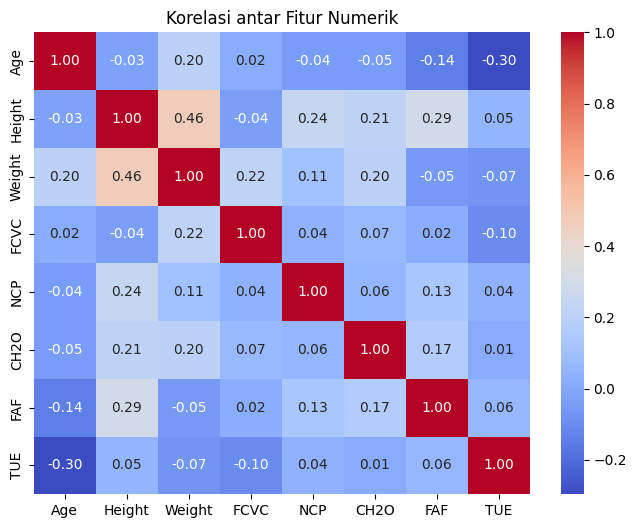

In [33]:
# Korelasi dan heatmap
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antar Fitur Numerik')
plt.show()


Dari heatmap ini, terlihat bahwa sebagian besar fitur memiliki korelasi yang rendah satu sama lain, ditunjukkan oleh nilai-nilai yang mendekati nol. Korelasi tertinggi tercatat antara Height dan Weight sebesar 0.46, yang menunjukkan hubungan positif sedang—semakin tinggi seseorang, biasanya berat badannya juga lebih tinggi. Sementara itu, hubungan negatif tertinggi adalah antara Age dan TUE dengan nilai -0.30, yang mengindikasikan bahwa semakin bertambah usia seseorang, cenderung waktu yang dihabiskan untuk aktivitas elektronik (TUE) semakin sedikit. Korelasi antar fitur lainnya, seperti antara FAF dengan CH2O, atau NCP dengan FCVC, menunjukkan nilai korelasi lemah, sehingga fitur-fitur tersebut relatif independen. Secara keseluruhan, tidak ditemukan korelasi tinggi antar fitur yang dapat menyebabkan multikolinearitas, sehingga seluruh fitur numerik ini layak untuk digunakan bersama dalam proses modeling machine learning.

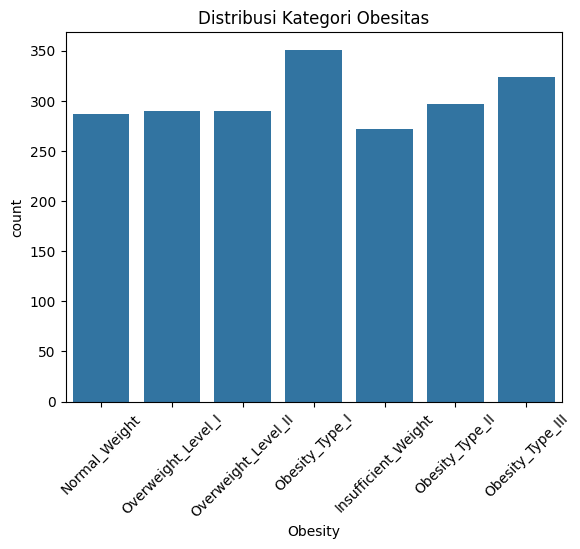

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Obesity')
plt.title('Distribusi Kategori Obesitas')
plt.xticks(rotation=45)
plt.show()


an distribusi kategori obesitas berdasarkan fitur target bernama "Obesity". Grafik batang ini menggambarkan jumlah data (sumbu y) untuk masing-masing kategori berat badan (sumbu x), mulai dari Insufficient_Weight hingga Obesity_Type_III. Distribusi terlihat relatif seimbang, artinya dataset ini tidak mengalami masalah ketidakseimbangan kelas (class imbalance) yang parah—sebuah kondisi penting untuk memastikan bahwa model klasifikasi tidak bias terhadap kelas mayoritas.

Kategori dengan jumlah tertinggi adalah Obesity_Type_I, diikuti oleh Obesity_Type_III dan Normal_Weight. Sementara itu, kategori dengan jumlah paling sedikit adalah Insufficient_Weight, meskipun selisihnya tidak terlalu besar dibanding kategori lain. Hal ini menunjukkan bahwa dataset mencakup representasi yang baik dari berbagai tingkat kondisi berat badan, mulai dari kekurangan hingga obesitas tingkat tinggi.

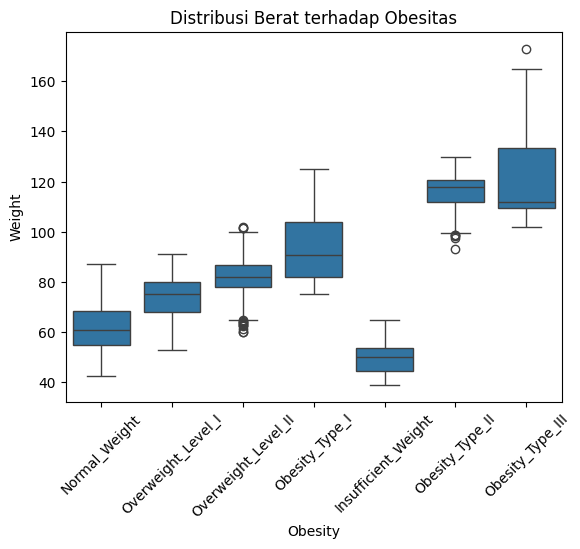

In [35]:
#Distribusi berat berdasarkan label obesitas
sns.boxplot(data=df, x='Obesity', y='Weight')
plt.xticks(rotation=45)
plt.title('Distribusi Berat terhadap Obesitas')
plt.show()


Gambar di atas menunjukkan boxplot distribusi berat badan terhadap kategori obesitas. Grafik ini menggambarkan bagaimana berat badan (Weight) tersebar di setiap kelas obesitas, mulai dari kategori Insufficient_Weight hingga Obesity_Type_III. Terlihat adanya pola yang jelas dan konsisten, yaitu semakin tinggi tingkat obesitas, maka semakin besar nilai median dan rentang berat badan. Kategori Insufficient_Weight memiliki median berat badan paling rendah, sementara Obesity_Type_III memiliki median tertinggi, bahkan lebih dari 120 kg, dengan rentang distribusi yang juga paling lebar. Setiap kategori menampilkan persebaran data dengan ukuran kotak (interquartile range) yang mencerminkan keragaman berat badan dalam kelompok tersebut, dan beberapa kategori juga menunjukkan adanya outlier, yaitu individu dengan berat badan yang sangat berbeda dari mayoritas kelompoknya.

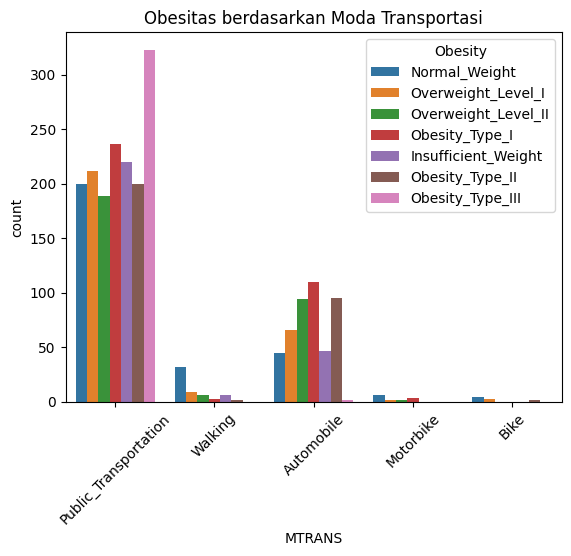

In [36]:
# Transportasi
sns.countplot(data=df, x='MTRANS', hue='Obesity')
plt.title('Obesitas berdasarkan Moda Transportasi')
plt.xticks(rotation=45)
plt.show()


Gambar di atas menunjukkan hubungan antara kategori obesitas dan jenis transportasi utama (MTRANS) yang digunakan oleh masing-masing orang. Dari grafik, terlihat bahwa transportasi umum (Public Transportation) adalah jenis transportasi yang paling banyak digunakan oleh semua kelompok, terutama oleh orang dengan kategori Obesity_Type_III. Artinya, meskipun mereka banyak menggunakan transportasi umum, tingkat obesitas tetap tinggi — kemungkinan karena faktor lain seperti pola makan atau kurang aktivitas fisik di luar perjalanan.

Kemudian, jenis transportasi mobil pribadi (Automobile) juga cukup sering digunakan, terutama oleh orang-orang yang masuk dalam kategori obesitas tingkat sedang hingga tinggi. Ini bisa menunjukkan bahwa orang dengan obesitas cenderung lebih sering menggunakan kendaraan yang tidak memerlukan banyak gerak.

Sebaliknya, orang yang berjalan kaki (Walking) atau menggunakan sepeda (Bike) lebih banyak berasal dari kelompok dengan berat badan normal atau kurang. Namun, jumlahnya jauh lebih sedikit dibanding yang menggunakan kendaraan umum atau mobil.

Secara keseluruhan, grafik ini memberi gambaran bahwa aktivitas fisik yang lebih banyak, seperti berjalan kaki atau bersepeda, berhubungan dengan berat badan yang lebih sehat. Sementara itu, penggunaan kendaraan pribadi cenderung dikaitkan dengan berat badan yang lebih tinggi.

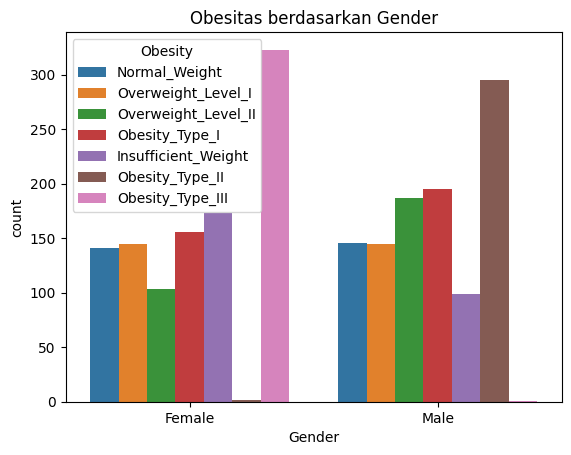

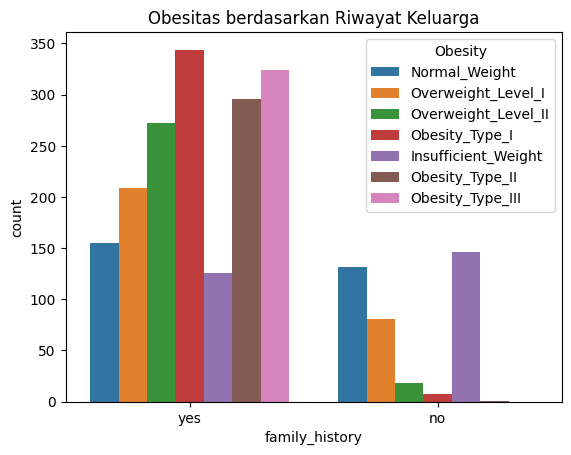

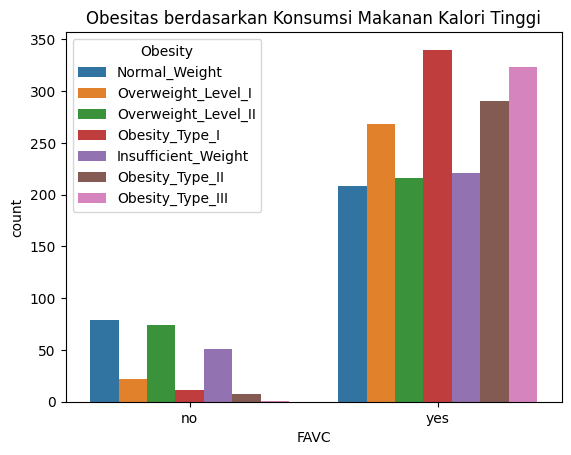

In [37]:
# Gender
sns.countplot(data=df, x='Gender', hue='Obesity')
plt.title('Obesitas berdasarkan Gender')
plt.show()

# Riwayat keluarga
sns.countplot(data=df, x='family_history', hue='Obesity')
plt.title('Obesitas berdasarkan Riwayat Keluarga')
plt.show()

# FAVC (makanan tinggi kalori)
sns.countplot(data=df, x='FAVC', hue='Obesity')
plt.title('Obesitas berdasarkan Konsumsi Makanan Kalori Tinggi')
plt.show()


**Gender**<br>
Grafik ini memperlihatkan bahwa distribusi obesitas berbeda antara perempuan (Female) dan laki-laki (Male) untuk tiap kategori berat badan. Pada kelompok perempuan, jumlah tertinggi berada pada kategori Obesity_Type_III, menunjukkan bahwa lebih banyak perempuan dalam data ini yang termasuk obesitas tingkat paling tinggi. Sementara itu, pada kelompok laki-laki, kategori paling dominan adalah Obesity_Type_II, yang juga menunjukkan tingkat obesitas yang cukup tinggi. Selain itu, laki-laki juga memiliki jumlah yang lebih tinggi dalam kategori Obesity_Type_I dan Overweight_Level_II dibanding perempuan.

Sebaliknya, kategori seperti Insufficient_Weight dan Normal_Weight memiliki jumlah yang seimbang antara laki-laki dan perempuan, meskipun sedikit lebih banyak pada perempuan untuk Insufficient_Weight.

Secara keseluruhan, grafik ini menunjukkan bahwa baik laki-laki maupun perempuan memiliki kecenderungan mengalami obesitas, tetapi jenis tingkat obesitas yang dominan berbeda. Perempuan lebih banyak di kategori obesitas paling tinggi, sedangkan laki-laki lebih banyak pada obesitas tingkat sedang.

**Family History**<br>

Grafik ini memperlihatkan bahwa mayoritas individu yang memiliki riwayat obesitas dalam keluarga ("yes") cenderung berada pada kategori obesitas, terutama pada kategori Obesity_Type_I, Obesity_Type_II, dan Obesity_Type_III, yang masing-masing jumlahnya cukup tinggi.

Sebaliknya, individu yang tidak memiliki riwayat obesitas keluarga ("no") lebih banyak ditemukan dalam kategori Normal_Weight dan Insufficient_Weight, dengan jumlah yang jauh lebih sedikit pada kategori obesitas.

Dari grafik ini, bisa disimpulkan bahwa riwayat obesitas dalam keluarga memiliki pengaruh kuat terhadap kemungkinan seseorang mengalami obesitas. Artinya, faktor genetik atau kebiasaan dalam keluarga kemungkinan besar berperan dalam meningkatkan risiko obesitas. Oleh karena itu, penting untuk memberikan perhatian lebih pada pencegahan obesitas pada individu yang memiliki riwayat keluarga dengan kondisi tersebut.

**FAVC**<br>
Berdasarkan data, individu dengan berat badan normal cenderung lebih sedikit mengonsumsi makanan kalori tinggi pada kategori "no" dibandingkan kategori "yes". Hal ini menunjukkan bahwa mereka yang memiliki berat badan normal lebih jarang mengonsumsi makanan kalori tinggi. Sementara itu, individu dengan overweight level I dan II menunjukkan kecenderungan yang lebih tinggi untuk mengonsumsi makanan kalori tinggi, dengan jumlah yang lebih besar pada kategori "yes" dibandingkan dengan kategori "no". Pada kategori obesitas tipe I, II, dan III, jumlah individu yang mengonsumsi makanan kalori tinggi lebih dominan pada kategori "yes", yang menunjukkan hubungan positif antara konsumsi makanan kalori tinggi dan tingkat obesitas yang lebih tinggi. Di sisi lain, individu dengan berat badan kurang (insufficient weight) cenderung lebih sedikit mengonsumsi makanan kalori tinggi dibandingkan dengan kategori lainnya. Secara keseluruhan, data ini mengindikasikan bahwa semakin tinggi tingkat obesitas seseorang, semakin besar kemungkinan mereka mengonsumsi makanan dengan kalori tinggi.

# Feature Engineering

In [38]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Obesity', errors='ignore')

skewed_feats = df[num_cols].apply(lambda x: skew(x.dropna()))
print("Skewness sebelum transformasi:\n", skewed_feats)

# Tampilkan fitur yang sangat skew
print("\nFitur dengan skewness > 1:")
print(skewed_feats[skewed_feats > 1])


Skewness sebelum transformasi:
 Age       1.528014
Height   -0.012846
Weight    0.255229
FCVC     -0.432598
NCP      -1.106310
CH2O     -0.104837
FAF       0.498135
TUE       0.618063
dtype: float64

Fitur dengan skewness > 1:
Age    1.528014
dtype: float64


In [39]:
# 2. Pisahkan fitur dan target
X = df.drop("Obesity", axis=1)
y = df["Obesity"]


In [40]:
numeric_cols_X = X.select_dtypes(include=np.number).columns.tolist()

print("Memulai pengecekan dan penanganan outlier...")
for col in numeric_cols_X:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Pengecekan Outlier
    outliers_count = X[(X[col] < lower_bound) | (X[col] > upper_bound)].shape[0]
    print(f"Kolom '{col}': Ditemukan {outliers_count} outlier.")


Memulai pengecekan dan penanganan outlier...
Kolom 'Age': Ditemukan 168 outlier.
Kolom 'Height': Ditemukan 1 outlier.
Kolom 'Weight': Ditemukan 1 outlier.
Kolom 'FCVC': Ditemukan 0 outlier.
Kolom 'NCP': Ditemukan 579 outlier.
Kolom 'CH2O': Ditemukan 0 outlier.
Kolom 'FAF': Ditemukan 0 outlier.
Kolom 'TUE': Ditemukan 0 outlier.


In [41]:
# Handling Outlier (Capping)
X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])
print(f"Outlier pada kolom '{col}' telah ditangani dengan capping.")
print("Selesai penanganan outlier.")

Outlier pada kolom 'TUE' telah ditangani dengan capping.
Selesai penanganan outlier.


In [42]:
# 3. Identifikasi kolom kategorikal dan numerik
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [43]:
# 4. Preprocessing Pipelines
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Normalisasi fitur numerik
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Encode target label
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [44]:
# 5. Split data (train-test)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#Model Definition

In [45]:
# 6. Inisialisasi model
models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'Boosting': GradientBoostingClassifier(random_state=42)
}


#Model Training and Evalution


Model: KNN
Classification Report (Test):
                      precision    recall  f1-score   support

Insufficient_Weight       0.80      0.94      0.86        54
      Normal_Weight       0.80      0.41      0.55        58
     Obesity_Type_I       0.79      0.94      0.86        70
    Obesity_Type_II       0.92      0.97      0.94        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.74      0.72      0.73        58
Overweight_Level_II       0.80      0.81      0.80        58

           accuracy                           0.83       423
          macro avg       0.83      0.83      0.82       423
       weighted avg       0.83      0.83      0.82       423

Classification Report (Train):
                      precision    recall  f1-score   support

Insufficient_Weight       0.83      0.98      0.89       218
      Normal_Weight       0.89      0.58      0.70       229
     Obesity_Type_I       0.91      0.95      0.93       281
    Ob

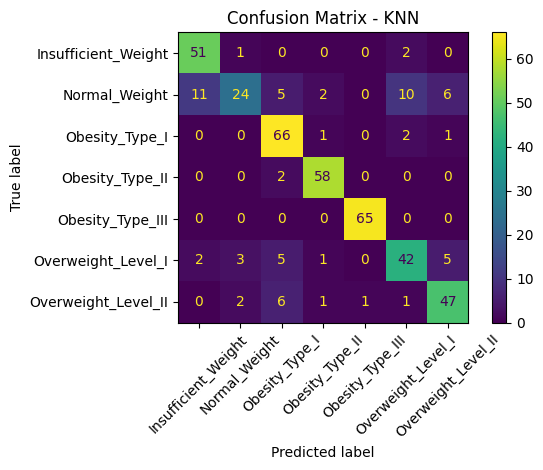


Model: SVM
Classification Report (Test):
                      precision    recall  f1-score   support

Insufficient_Weight       0.96      0.98      0.97        54
      Normal_Weight       0.83      0.84      0.84        58
     Obesity_Type_I       0.94      0.96      0.95        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.80      0.84      0.82        58
Overweight_Level_II       0.92      0.83      0.87        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423

Classification Report (Train):
                      precision    recall  f1-score   support

Insufficient_Weight       0.95      0.96      0.95       218
      Normal_Weight       0.89      0.85      0.87       229
     Obesity_Type_I       0.97      0.96      0.97       281
    Ob

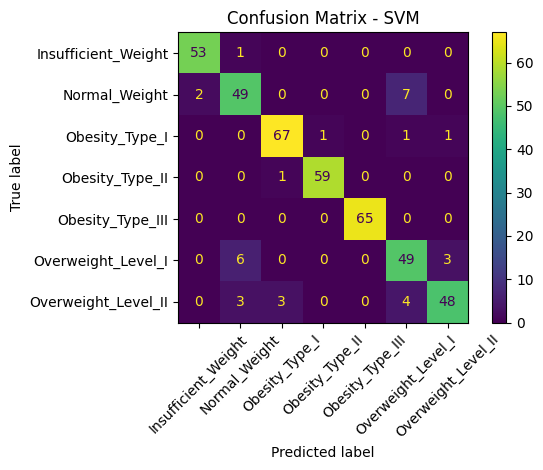


Model: DecisionTree
Classification Report (Test):
                      precision    recall  f1-score   support

Insufficient_Weight       0.98      0.87      0.92        54
      Normal_Weight       0.78      0.84      0.81        58
     Obesity_Type_I       0.94      0.93      0.94        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.84      0.88      0.86        58
Overweight_Level_II       0.93      0.93      0.93        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423

Classification Report (Train):
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       218
      Normal_Weight       1.00      1.00      1.00       229
     Obesity_Type_I       1.00      1.00      1.00       2

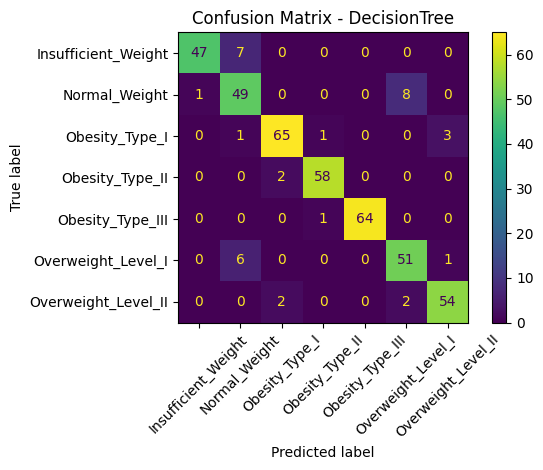


Model: RandomForest
Classification Report (Test):
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.82      0.97      0.89        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.88      0.91        58
Overweight_Level_II       0.96      0.95      0.96        58

           accuracy                           0.95       423
          macro avg       0.96      0.95      0.95       423
       weighted avg       0.96      0.95      0.95       423

Classification Report (Train):
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       218
      Normal_Weight       1.00      1.00      1.00       229
     Obesity_Type_I       1.00      1.00      1.00       2

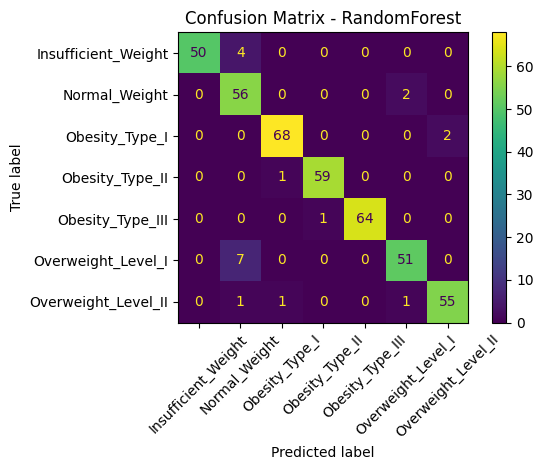


Model: Boosting
Classification Report (Test):
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      0.91      0.95        54
      Normal_Weight       0.85      0.98      0.91        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.91      0.92        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423

Classification Report (Train):
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       218
      Normal_Weight       1.00      1.00      1.00       229
     Obesity_Type_I       1.00      1.00      1.00       281
 

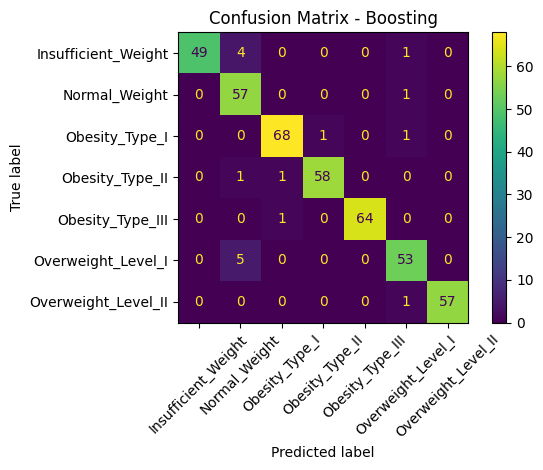

In [ ]:
# 7. Pipeline, Evaluasi, dan Cross Validation
results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('clf', model)
    ])
    print(f"\nModel: {name}")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_train_pred = pipe.predict(X_train)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    print("Classification Report (Test):\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_))
    print("Classification Report (Train):\n", classification_report(y_train, y_train_pred, target_names=target_encoder.classes_))
    print(f"Cross-Validation Accuracy (mean ± std): {scores.mean():.4f} ± {scores.std():.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
    disp.plot(xticks_rotation=45)
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1_score': f1,
        'cv_mean': scores.mean(),
        'cv_std': scores.std()
    }

##KNN (K-Nearest Neighbors)

 Model KNN menunjukkan hasil yang cukup baik pada data uji dan data pelatihan. Untuk kategori Obesity Type I, Obesity Type II, dan Obesity Type III, model menunjukkan hasil yang sangat baik, dengan precision dan recall yang tinggi, terutama pada Obesity Type III yang mencapai precision 1.00 dan recall 0.99, menandakan bahwa model sangat efektif dalam mengklasifikasikan kategori ini. Obesity Type II juga menunjukkan performa yang solid dengan precision 0.97 dan recall 0.96. Namun, kategori Normal Weight menunjukkan kinerja yang lebih rendah dengan precision 0.80 dan recall 0.41, yang berarti model kesulitan dalam mengklasifikasikan individu dengan berat badan normal, menghasilkan banyak kesalahan klasifikasi ke kategori obesitas. Selain itu, Overweight Level I juga memiliki precision 0.74 dan recall 0.79, menunjukkan bahwa model agak kurang baik dalam mengidentifikasi individu dalam kategori ini, meskipun Overweight Level II memiliki hasil yang lebih baik dengan precision 0.88 dan recall 0.80. Cross-validation accuracy model adalah 0.8276 ± 0.0508

 Confusion Matrix untuk model KNN, yang menggambarkan distribusi prediksi yang benar dan salah antara label yang sebenarnya dan yang diprediksi. Model ini menunjukkan hasil yang baik dalam mengklasifikasikan sebagian besar kategori obesitas. Obesity Type I memiliki 66 prediksi yang benar, meskipun ada beberapa kesalahan klasifikasi ke Obesity Type II, yang menunjukkan kinerja yang baik pada kategori ini. Obesity Type II menunjukkan 58 prediksi benar, dengan beberapa kesalahan ke Obesity Type I dan Obesity Type III, namun tetap menunjukkan performa yang solid. Obesity Type III memiliki 65 prediksi yang benar, dengan sedikit kesalahan klasifikasi, menunjukkan bahwa model efektif dalam mengidentifikasi individu dengan obesitas tipe III. Di sisi lain, Normal Weight menunjukkan hasil yang kurang baik, dengan 24 prediksi yang benar, dan banyak individu yang salah diklasifikasikan ke kategori Obesity Type I dan Obesity Type II, yang menandakan bahwa model kesulitan dalam mengklasifikasikan kategori berat badan normal. Overweight Level I dan Overweight Level II masing-masing memiliki 42 dan 47 prediksi yang benar, meskipun ada beberapa kesalahan klasifikasi ke kategori lain. Insufficient Weight juga menunjukkan hasil yang baik dengan 51 prediksi yang benar, meskipun ada kesalahan klasifikasi.

##SVM

Model SVM menunjukkan hasil yang sangat baik baik pada data uji (Test) maupun data pelatihan (Train). Pada data uji, model menunjukkan precision dan recall yang sangat tinggi untuk kategori Obesity Type III, masing-masing 1.00, yang menandakan bahwa model sangat efektif dalam mengklasifikasikan individu dengan obesitas tipe III. Kategori Obesity Type I dan Obesity Type II juga menunjukkan hasil yang sangat baik dengan nilai precision dan recall di atas 0.98, menunjukkan kemampuan model yang sangat baik dalam mengidentifikasi individu dengan obesitas tipe I dan II. Pada kategori Normal Weight, model memiliki precision 0.83 dan recall 0.84, yang menunjukkan kinerja yang cukup baik meskipun ada sedikit kesalahan klasifikasi ke kategori lain. Sementara itu, kategori Overweight Level I memiliki precision 0.88 dan recall 0.84, dan Overweight Level II memiliki precision 0.92 dan recall 0.83, keduanya menunjukkan hasil yang solid meskipun ada beberapa kesalahan prediksi. Cross-validation accuracy sebesar 0.8954 ± 0.8648 menunjukkan stabilitas yang baik dengan sedikit variasi antara fold, yang menandakan bahwa model ini konsisten memberikan hasil yang sangat baik. Secara keseluruhan, model SVM menunjukkan performa yang sangat baik dalam mengklasifikasikan kategori obesitas, dengan kinerja terbaik pada kategori Obesity Type III, meskipun terdapat beberapa kesalahan klasifikasi pada Normal Weight dan Overweight Level I.

Confusion Matrix untuk model SVM, yang menggambarkan distribusi prediksi yang benar dan salah antara label yang sebenarnya dan yang diprediksi. Model ini menunjukkan hasil yang sangat baik dalam mengklasifikasikan kategori Obesity Type I, dengan 67 prediksi yang benar, meskipun ada beberapa kesalahan klasifikasi ke kategori Obesity Type II dan Obesity Type III. Obesity Type II juga menunjukkan hasil yang baik dengan 59 prediksi yang benar, meskipun ada kesalahan ke kategori lain, terutama Obesity Type I dan Obesity Type III. Obesity Type III menunjukkan 65 prediksi yang benar dengan kesalahan klasifikasi minimal. Namun, model ini sedikit kesulitan dalam mengklasifikasikan kategori Normal Weight, dengan 49 prediksi yang benar dan beberapa individu salah diklasifikasikan ke kategori Obesity Type I dan Obesity Type III. Untuk kategori Overweight Level I dan Overweight Level II, model memberikan 49 dan 48 prediksi yang benar, meskipun ada beberapa kesalahan klasifikasi. Sedangkan untuk Insufficient Weight, model menunjukkan hasil yang solid dengan 53 prediksi yang benar, meskipun ada kesalahan prediksi ke Normal Weight. Secara keseluruhan, meskipun ada beberapa kesalahan pada kategori Normal Weight, model SVM menunjukkan performa yang sangat baik dalam mengklasifikasikan kategori obesitas dengan akurasi yang tinggi.

##Decision Tree

Model Decision Tree menunjukkan hasil yang sangat baik pada data uji (Test) dan data pelatihan (Train). Pada data uji, model menunjukkan precision, recall, dan f1-score yang sangat tinggi di hampir semua kategori. Untuk Obesity Type III, model mencapai precision 1.00 dan recall 0.98, menunjukkan bahwa model sangat akurat dalam mengklasifikasikan individu dengan obesitas tipe III. Obesity Type I dan Obesity Type II juga menunjukkan hasil yang sangat baik dengan precision di atas 0.97 dan recall lebih dari 0.97, menandakan bahwa model ini sangat efektif dalam mengidentifikasi individu dengan obesitas tipe I dan II.

Kategori Normal Weight menunjukkan precision 0.78 dan recall 0.84 pada data uji, yang berarti bahwa model ini memiliki kinerja lebih rendah pada kategori berat badan normal, dengan kesalahan klasifikasi yang lebih tinggi. Pada Overweight Level I, model memiliki precision 0.88 dan recall 0.88, yang menunjukkan hasil yang baik, meskipun masih ada beberapa kesalahan klasifikasi.

Pada data pelatihan, model Decision Tree menunjukkan hasil yang hampir sempurna, dengan precision, recall, dan f1-score mencapai 1.00 di semua kategori, menunjukkan bahwa model sangat baik dalam mempelajari data pelatihan. Hasil cross-validation accuracy yang sebesar 0.9257 ± 0.0422 menunjukkan stabilitas model yang baik

- **Obesity Type I, II, III:**
    1. Obesity Type I memiliki 65 prediksi benar, dengan beberapa kesalahan ke Obesity Type II dan Obesity Type III, yang menunjukkan hasil yang sangat baik dalam mengklasifikasikan kategori ini.
    2. Obesity Type II menunjukkan 58 prediksi benar, dengan sedikit kesalahan klasifikasi ke kategori Obesity Type I.
    3. Obesity Type III memiliki 64 prediksi benar, dengan sangat sedikit kesalahan klasifikasi ke kategori lain, menunjukkan performa yang sangat baik.

- **Normal Weight:**
    Normal Weight memiliki 49 prediksi benar, dengan beberapa kesalahan yang cukup signifikan ke kategori Obesity Type I (8 kesalahan). Model kesulitan sedikit dalam mengklasifikasikan individu dengan berat badan normal dengan akurat.

- **Overweight Level I dan II:**
    1. Overweight Level I memiliki 51 prediksi benar, meskipun ada 6 kesalahan klasifikasi ke kategori lain, terutama ke Obesity Type I.
    2. Overweight Level II menunjukkan 54 prediksi benar, dengan sedikit kesalahan yang masuk ke kategori Obesity Type I.

- **Insufficient Weight:**
    Insufficient Weight memiliki 47 prediksi benar, meskipun ada 7 kesalahan yang masuk ke kategori Normal Weight.

**Kesimpulan:**
Secara keseluruhan, model Decision Tree menunjukkan hasil yang sangat baik dalam mengklasifikasikan kategori obesitas dengan sedikit kesalahan pada sebagian besar kategori, terutama Obesity Type I dan Obesity Type III. Namun, model ini sedikit kesulitan dalam mengklasifikasikan Normal Weight dengan akurat, yang menyebabkan lebih banyak kesalahan pada kategori ini.

##Random Forest

Model Random Forest menunjukkan hasil yang sangat baik baik pada data uji (Test) maupun data pelatihan (Train). Model ini sangat efektif dalam mengklasifikasikan kategori Obesity Type I, Obesity Type II, dan Obesity Type III, dengan precision, recall, dan f1-score yang sangat tinggi, masing-masing mencapai 1.00 dan 0.98, menunjukkan kemampuan yang sangat baik dalam mengidentifikasi individu dengan obesitas tipe I dan III. Kategori Normal Weight memiliki precision 0.82 dan recall 0.97 pada data uji, yang berarti meskipun ada beberapa kesalahan klasifikasi, model cukup baik dalam mengidentifikasi individu dengan berat badan normal. Untuk kategori Overweight Level I dan Overweight Level II, model juga menunjukkan hasil yang sangat baik, dengan precision 0.94 dan 0.96 serta recall 0.95 dan 0.95, yang menandakan performa yang solid dengan sedikit kesalahan klasifikasi. Cross-validation accuracy sebesar 0.9366 ± 0.0960[teks link](https://)

**Obesity Type I, II, III:**

*   Obesity Type I memiliki 68 prediksi yang benar, dengan sangat sedikit kesalahan klasifikasi ke kategori Obesity Type II dan Obesity Type III, yang menunjukkan bahwa model sangat baik dalam mengklasifikasikan kategori ini.
*   Obesity Type II menunjukkan 59 prediksi yang benar, dengan beberapa kesalahan klasifikasi ke Obesity Type I dan Obesity Type III, tetapi hasilnya tetap sangat baik.
*   Obesity Type III menunjukkan 64 prediksi yang benar dengan hanya sedikit kesalahan, yang menunjukkan bahwa model efektif dalam mengidentifikasi individu dengan obesitas tipe III.

**Normal Weight:**

*   Normal Weight memiliki 56 prediksi yang benar, namun ada 7 individu yang salah diklasifikasikan sebagai Overweight Level I, yang menunjukkan bahwa model sedikit kesulitan dalam mengklasifikasikan kategori berat badan normal dengan akurat.

**Overweight Level I dan II:**

*   Overweight Level I menunjukkan 51 prediksi yang benar, dengan beberapa kesalahan yang terklasifikasi sebagai Obesity Type I.
*   Overweight Level II memiliki 55 prediksi yang benar, dengan beberapa kesalahan diklasifikasikan sebagai Obesity Type I dan Obesity Type III.

**Insufficient Weight:**

*   Insufficient Weight memiliki 50 prediksi yang benar, dengan beberapa kesalahan klasifikasi ke kategori Normal Weight.

**Kesimpulan:**
Secara keseluruhan, model Random Forest menunjukkan hasil yang sangat baik dalam mengklasifikasikan kategori obesitas, terutama pada Obesity Type I dan Obesity Type III, dengan sedikit kesalahan klasifikasi. Meskipun ada beberapa kesalahan pada kategori Normal Weight dan Overweight Level I, model ini tetap menunjukkan performa yang solid dengan tingkat akurasi yang tinggi.

## Boosting

Pada data uji, model menunjukkan precision, recall, dan f1-score yang tinggi di sebagian besar kategori. Kategori Obesity Type III dan Obesity Type I memiliki precision dan recall yang sempurna (1.00), yang menunjukkan bahwa model sangat efektif dalam mengklasifikasikan individu dengan obesitas tipe III dan I. Kategori Obesity Type II dan Overweight Level I juga menunjukkan hasil yang sangat baik, dengan precision dan recall di atas 0.97. Normal Weight sedikit lebih rendah dengan precision 0.85, namun recall-nya tetap tinggi (0.98), yang menunjukkan bahwa model masih cukup efektif dalam mengidentifikasi individu dengan berat badan normal.

Pada data pelatihan, model Boosting menunjukkan performa yang sempurna dengan precision, recall, dan f1-score semuanya mencapai 1.00 di semua kategori. Ini menunjukkan bahwa model sangat efektif dalam mempelajari data pelatihan dan memberikan klasifikasi yang sangat akurat. Hasil cross-validation accuracy sebesar 0.9413 ± 0.0784

Confusion Matrix pada Model Boosting<br>
**Obesity Type I, II, III:**

*   Obesity Type I memiliki 68 prediksi yang benar, dengan sedikit kesalahan klasifikasi ke kategori Obesity Type II dan Obesity Type III, yang menunjukkan bahwa model sangat baik dalam mengklasifikasikan kategori ini.
*   Obesity Type II menunjukkan 58 prediksi yang benar, dengan beberapa kesalahan klasifikasi ke kategori Obesity Type I dan Obesity Type III, namun tetap memberikan performa yang solid.
*   Obesity Type III memiliki 64 prediksi yang benar, dengan sedikit kesalahan klasifikasi ke kategori lain, menunjukkan kinerja yang baik pada kategori ini.

**Normal Weight:**

*   Normal Weight memiliki 57 prediksi yang benar, namun ada 5 individu yang salah diklasifikasikan sebagai Overweight Level I. Model ini sedikit kesulitan dalam mengklasifikasikan kategori berat badan normal, tetapi hasilnya tetap baik.

**Overweight Level I dan II:**

*   Overweight Level I memiliki 53 prediksi yang benar, dengan beberapa kesalahan klasifikasi ke Obesity Type I.
*   Overweight Level II menunjukkan 57 prediksi yang benar, dengan sedikit kesalahan klasifikasi ke kategori Obesity Type I.

**Insufficient Weight:**

*   Insufficient Weight memiliki 49 prediksi yang benar, dengan beberapa kesalahan yang masuk ke kategori Normal Weight.

## Kesimpulan

Kesimpulan dari hasil model klasifikasi untuk berbagai algoritma (KNN, SVM, Decision Tree, Random Forest, dan Boosting) ini adalah sebagai berikut:

**1. Performa Model:** <br>Semua model menunjukkan performansi yang sangat baik dalam mengklasifikasikan berbagai kategori obesitas, dengan accuracy yang tinggi pada data pelatihan dan data uji. Secara keseluruhan, model-model ini efektif dalam mengidentifikasi individu dengan tingkat obesitas yang lebih tinggi (Obesity Type I, II, III), meskipun ada sedikit penurunan pada kategori Normal Weight.

**Keunggulan Masing-Masing Model:**

- KNN dan SVM menunjukkan precision dan recall yang sangat tinggi, terutama untuk kategori Obesity Type III dan Obesity Type I.

- Decision Tree dan Random Forest sangat baik dalam mempelajari data pelatihan, dengan accuracy mencapai 1.00 pada data pelatihan dan sedikit kesalahan pada data uji.

- Boosting memiliki precision dan recall yang hampir sempurna di sebagian besar kategori, terutama pada Obesity Type III, dengan cross-validation accuracy yang menunjukkan stabilitas model yang baik.

**2. Confusion Matrix:**<br> Semua model menunjukkan kesalahan klasifikasi yang sangat sedikit, meskipun kategori Normal Weight mengalami lebih banyak kesalahan, di mana beberapa individu salah diklasifikasikan ke kategori obesitas yang lebih tinggi. Namun, ini tetap menunjukkan bahwa model cukup efektif dalam membedakan antara kategori-kategori berat badan normal dan obesitas.

**3. Konsistensi Model:** <br> Secara keseluruhan, model-model ini konsisten dalam memberikan hasil yang baik di berbagai kondisi, dengan sedikit variasi pada cross-validation accuracy yang menunjukkan kestabilan dan generalisasi model.

Secara keseluruhan, model Boosting dan Random Forest menunjukkan performa yang paling konsisten dan efektif, dengan accuracy yang sangat baik baik pada data pelatihan maupun data uji. Meskipun ada sedikit kesalahan pada kategori Normal Weight, semua model dapat diandalkan untuk klasifikasi obesitas dalam berbagai kategori dengan tingkat akurasi yang tinggi.

In [47]:
# 8. Seleksi Model Terbaik
best_model_name = max(results, key=lambda name: results[name]['cv_mean'])
best_model = results[best_model_name]['model']
print(f"\nModel terbaik berdasarkan CV Accuracy: {best_model_name}")


Model terbaik berdasarkan CV Accuracy: Boosting



Best Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Tuned Boosting Report (Test):
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      0.91      0.95        54
      Normal_Weight       0.86      0.98      0.92        58
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.93      0.95        58
Overweight_Level_II       0.98      1.00      0.99        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423

Tuned Boosting Report (Train):
                      precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       218
      Normal_Weight       1.00      1.00      1.00  

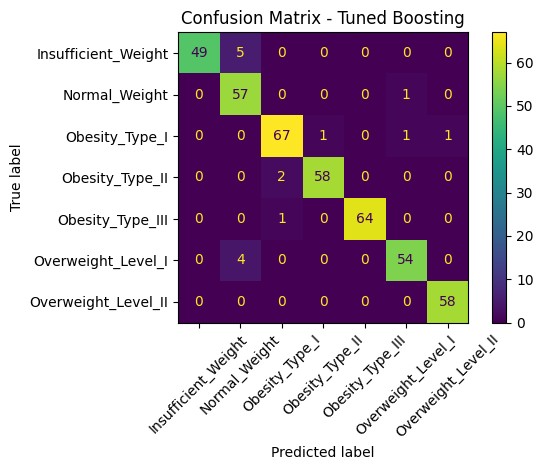

In [48]:
# 9. Hyperparameter Tuning pada model terbaik jika Boosting
if best_model_name == 'Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    }
    grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)
    best_estimator = grid.best_estimator_
    print("\nBest Boosting Parameters:", grid.best_params_)
    y_pred_best = best_estimator.predict(X_test)
    print("\nTuned Boosting Report (Test):\n", classification_report(y_test, y_pred_best, target_names=target_encoder.classes_))
    y_train_pred_best = best_estimator.predict(X_train)
    print("Tuned Boosting Report (Train):\n", classification_report(y_train, y_train_pred_best, target_names=target_encoder.classes_))
    cm_best = confusion_matrix(y_test, y_pred_best)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=target_encoder.classes_)
    disp.plot(xticks_rotation=45)
    plt.title("Confusion Matrix - Tuned Boosting")
    plt.tight_layout()
    plt.show()
else:
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)
    y_train_pred_best = best_model.predict(X_train)
    print(f"\nEvaluation for Final Model ({best_model_name}):")
    print("Classification Report (Test):\n", classification_report(y_test, y_pred_best, target_names=target_encoder.classes_))
    print("Classification Report (Train):\n", classification_report(y_train, y_train_pred_best, target_names=target_encoder.classes_))
    cm_best = confusion_matrix(y_test, y_pred_best)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=target_encoder.classes_)
    disp.plot(xticks_rotation=45)
    plt.title(f"Confusion Matrix - Final {best_model_name}")
    plt.tight_layout()
    plt.show()

Perbandingan antara Confusion Matrix model Boosting yang sudah dituning (Tuned Boosting) dan model Boosting yang sebelumnya menunjukkan beberapa perbedaan penting, meskipun keduanya menunjukkan performa yang sangat baik:

**1. Obesity Type I, II, III:** <br>

Pada model Tuned Boosting, Obesity Type I memiliki 67 prediksi benar, sedikit lebih tinggi dari 68 pada model sebelumnya, menunjukkan peningkatan akurasi dalam mengklasifikasikan kategori ini.

**2. Obesity Type III** <br>tetap menunjukkan 64 prediksi benar pada kedua gambar, dengan perbedaan yang sangat kecil.

**3. Obesity Type II**<br> menunjukkan 58 prediksi benar pada model sebelumnya dan 59 pada model yang sudah dituning, yang menunjukkan sedikit peningkatan.

**4. Normal Weight:**<br>

Normal Weight pada kedua model menunjukkan 57 prediksi benar, yang tetap konsisten antara model sebelumnya dan model yang sudah dituning.

**5. Overweight Level I dan II:**<br>

Pada Overweight Level I, model yang sudah dituning menunjukkan 54 prediksi benar, sedangkan model sebelumnya memiliki 53 prediksi benar.

**6. Overweight Level II**<br> menunjukkan 58 prediksi benar pada kedua model, yang tetap konsisten.

**7. Insufficient Weight:**<br>

Insufficient Weight pada kedua model menunjukkan 49 prediksi benar, tanpa ada perbedaan signifikan antara model sebelumnya dan model yang sudah dituning.

**8. Kesalahan Klasifikasi:**<br>

Pada model Tuned Boosting, ada sedikit pengurangan kesalahan klasifikasi, terutama pada kategori Normal Weight, yang sebelumnya salah diklasifikasikan sebagai Obesity Type I (1 kesalahan), sementara pada model sebelumnya, lebih banyak kesalahan.

**Kesimpulan:**
Perbandingan ini menunjukkan bahwa model Boosting yang sudah dituning sedikit lebih baik dalam mengklasifikasikan Obesity Type I dan Obesity Type II dibandingkan model sebelumnya, dengan sedikit peningkatan dalam accuracy pada kategori-kategori tersebut. Secara keseluruhan, tuning model menghasilkan peningkatan kecil dalam akurasi dan sedikit mengurangi kesalahan klasifikasi pada kategori tertentu, meskipun perbedaannya tidak terlalu signifikan.